# DSPy-Style Fixer Agent Prompt Optimization

Improvements over `train_fixer_agent.ipynb`:
- **N=5 candidates per iteration** instead of 1 — far less likely to get stuck
- **13 train images** instead of 3 — statistically stable selection
- **Temperature fixed at 0.0** for deterministic, reproducible fixer calls
- **Variance-penalized composite score**: `mean_TEDS - 0.5 * std_TEDS`
- **Few-shot bootstrapping** from high-scoring training pairs
- **Diversity tracking** via prompt embeddings to detect candidate collapse

Loop per iteration:
1. Evaluate current best prompt on all train images
2. Collect few-shot examples from high-TEDS training pairs
3. Generate N candidate system prompts in parallel (async, varied meta-temp)
4. Score all candidates on train set (parallelized fixer calls per candidate)
5. Select best by composite score; track diversity

In [39]:
import json
import re
import sys
import random
import base64
import io
import time
import asyncio
import concurrent.futures
import statistics
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()  # allow asyncio.run() inside Jupyter's running event loop

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML
from bs4 import BeautifulSoup
from pydantic import BaseModel

# Project paths
project_root = Path.cwd().parent
huma_root = project_root / "Huma-Huma"
for p in [project_root, huma_root, huma_root / "unitable", project_root / "pubtabnet" / "src"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from google.genai import types as genai_types
from metric import TEDS
from shared.client import client, DEFAULT_MODEL

print(f"Model: {DEFAULT_MODEL}")
print("Imports OK")

Model: gemini-3-flash-preview
Imports OK


In [40]:
# ── Smoke-test values (flip to full when pipeline is verified) ───────────────
SMOKE_TEST = False

# ── Data split ───────────────────────────────────────────────────────────────
TRAIN_SIZE = 3  if SMOKE_TEST else 13
TEST_SIZE  = 2  if SMOKE_TEST else 7

# ── DSPy loop ────────────────────────────────────────────────────────────────
N_CANDIDATES   = 2  if SMOKE_TEST else 5
MAX_ITERATIONS = 2  if SMOKE_TEST else 8
TARGET_COMPOSITE = 0.97
PLATEAU_WINDOW   = 3

# ── Scoring ──────────────────────────────────────────────────────────────────
BETA = 0.5               # composite = mean_teds - BETA * std_teds

# ── Few-shot bootstrapping ───────────────────────────────────────────────────
FEWSHOT_TEDS_THRESHOLD = 0.98
MAX_FEWSHOT_EXAMPLES   = 3

# ── Meta-prompt temperatures ─────────────────────────────────────────────────
META_TEMPERATURES = [0.7, 0.9, 1.0, 1.1, 1.3]

# ── Fixer ────────────────────────────────────────────────────────────────────
FIXER_TEMPERATURE = 0.0
EVAL_WORKERS      = 8

random.seed(42)

print(f"{'[SMOKE TEST]' if SMOKE_TEST else '[FULL RUN]'}")
print(f"Train: {TRAIN_SIZE}, Test: {TEST_SIZE}, Candidates: {N_CANDIDATES}, Max iters: {MAX_ITERATIONS}")
print(f"Composite = mean_TEDS - {BETA} * std_TEDS, target: {TARGET_COMPOSITE}")

[FULL RUN]
Train: 13, Test: 7, Candidates: 5, Max iters: 8
Composite = mean_TEDS - 0.5 * std_TEDS, target: 0.97


## Load PubTabNet ground truth

In [41]:
def format_html_clean(img):
    """Build GT HTML from PubTabNet annotation without prettify whitespace."""
    html_string = '<html><body><table>%s</table></body></html>' % ''.join(img['html']['structure']['tokens'])
    cell_nodes = list(re.finditer(r'(<td[^<>]*>)(</td>)', html_string))
    cells = [''.join(c['tokens']) for c in img['html']['cells']]
    offset = 0
    for n, cell in zip(cell_nodes, cells):
        html_string = html_string[:n.end(1) + offset] + cell + html_string[n.start(2) + offset:]
        offset += len(cell)
    return html_string

gt_path = project_root / "pubtabnet" / "examples" / "PubTabNet_Examples.jsonl"
img_dir = project_root / "pubtabnet" / "examples"

gt_data = []
with open(gt_path) as f:
    for line in f:
        ex = json.loads(line)
        img_path = img_dir / ex["filename"]
        if img_path.exists():
            gt_data.append({"filename": ex["filename"], "image_path": img_path, "gt_html": format_html_clean(ex)})

# Two TEDS scorers — also instantiated fresh per thread inside score_candidate
teds_scorer    = TEDS(structure_only=False)
teds_structure = TEDS(structure_only=True)

print(f"Loaded {len(gt_data)} images with ground truth")

Loaded 20 images with ground truth


## Train / test split

In [42]:
random.shuffle(gt_data)
train_data = gt_data[:TRAIN_SIZE]
test_data  = gt_data[TRAIN_SIZE:TRAIN_SIZE + TEST_SIZE]

print(f"Train ({len(train_data)}):")
for d in train_data: print(f"  {d['filename']}")
print(f"\nTest ({len(test_data)}):")
for d in test_data:  print(f"  {d['filename']}")

Train (13):
  PMC5402779_004_00.png
  PMC5897438_004_00.png
  PMC2759935_007_01.png
  PMC2838834_005_00.png
  PMC5679144_002_01.png
  PMC5577841_001_00.png
  PMC4003957_018_00.png
  PMC5332562_005_00.png
  PMC3907710_006_00.png
  PMC3826085_003_00.png
  PMC4172848_007_00.png
  PMC5134617_013_00.png
  PMC4517499_004_00.png

Test (7):
  PMC2753619_002_00.png
  PMC4776821_005_00.png
  PMC4682394_003_00.png
  PMC3519711_003_00.png
  PMC5198506_004_00.png
  PMC4840965_004_00.png
  PMC1626454_002_00.png


## Load UniTable (local MPS)

In [43]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "unitable_extractor",
    str(huma_root / "table_extraction" / "unitable.py")
)
unitable_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unitable_mod)

extractor = unitable_mod.UniTableExtractor()
print(f"UniTable device: {extractor.device}")

Loading UniTable models...
  ✓ Structure model loaded
  ✓ Bbox model loaded
  ✓ Content model loaded
UniTable ready for inference!
UniTable device: mps


## Pre-extract UniTable HTML for all images

Run UniTable once and cache results — deterministic and expensive. Also cache PIL Image objects to avoid repeated file I/O during the eval loop.

In [44]:
unitable_cache: dict[str, str]         = {}
image_cache:    dict[str, Image.Image] = {}

all_data = train_data + test_data
for i, item in enumerate(all_data):
    fname = item["filename"]
    image = Image.open(item["image_path"]).convert("RGB")
    image_cache[fname] = image
    print(f"  [{i+1}/{len(all_data)}] UniTable: {fname} ... ", end="", flush=True)
    t0 = time.time()
    try:
        unitable_cache[fname] = extractor.extract_html(image)
        print(f"{time.time()-t0:.1f}s")
    except Exception as e:
        unitable_cache[fname] = ""
        print(f"FAILED: {e}")

print(f"\nCached: {sum(1 for v in unitable_cache.values() if v)}/{len(all_data)} images")

  [1/20] UniTable: PMC5402779_004_00.png ... 44.1s
  [2/20] UniTable: PMC5897438_004_00.png ... 18.6s
  [3/20] UniTable: PMC2759935_007_01.png ... 91.1s
  [4/20] UniTable: PMC2838834_005_00.png ... 201.7s
  [5/20] UniTable: PMC5679144_002_01.png ... 20.2s
  [6/20] UniTable: PMC5577841_001_00.png ... 22.5s
  [7/20] UniTable: PMC4003957_018_00.png ... 109.0s
  [8/20] UniTable: PMC5332562_005_00.png ... 156.8s
  [9/20] UniTable: PMC3907710_006_00.png ... 31.4s
  [10/20] UniTable: PMC3826085_003_00.png ... 91.3s
  [11/20] UniTable: PMC4172848_007_00.png ... 163.0s
  [12/20] UniTable: PMC5134617_013_00.png ... 59.3s
  [13/20] UniTable: PMC4517499_004_00.png ... 29.3s
  [14/20] UniTable: PMC2753619_002_00.png ... 30.0s
  [15/20] UniTable: PMC4776821_005_00.png ... 33.0s
  [16/20] UniTable: PMC4682394_003_00.png ... 82.3s
  [17/20] UniTable: PMC3519711_003_00.png ... 36.1s
  [18/20] UniTable: PMC5198506_004_00.png ... 11.8s
  [19/20] UniTable: PMC4840965_004_00.png ... 51.7s
  [20/20] UniTabl

## Core helper functions

In [45]:
def hybrid_extract(image: Image.Image, unitable_html: str, system_prompt: str) -> str:
    """Run Gemini fixer at T=0.0. Returns corrected HTML, original if NO_CHANGES, or '' on failure."""
    if not unitable_html:
        return ""
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    img_bytes = buf.getvalue()

    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[
            {"inline_data": {"mime_type": "image/png", "data": base64.b64encode(img_bytes).decode()}},
            f"Here is the UniTable HTML to correct:\n\n{unitable_html}",
        ],
        config={"system_instruction": system_prompt, "temperature": FIXER_TEMPERATURE},
    )
    text = response.text.strip()
    if text == "NO_CHANGES":
        return unitable_html
    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text


def score_candidate(system_prompt: str, data: list) -> dict:
    """Evaluate one candidate prompt on a dataset using a thread pool.
    
    TEDS is not thread-safe — each worker instantiates its own scorer.
    Returns {mean_teds, std_teds, composite, per_image}.
    """
    per_image = [None] * len(data)

    def _eval_one(args):
        idx, item = args
        fname   = item["filename"]
        image   = image_cache[fname]
        ut_html = unitable_cache.get(fname, "")
        gt_html = item["gt_html"]
        # Thread-local TEDS instances
        _teds_full   = TEDS(structure_only=False)
        _teds_struct = TEDS(structure_only=True)
        try:
            pred_html = hybrid_extract(image, ut_html, system_prompt)
        except Exception:
            pred_html = ""
        teds_full   = _teds_full.evaluate(pred_html, gt_html)   if pred_html else 0.0
        teds_struct = _teds_struct.evaluate(pred_html, gt_html) if pred_html else 0.0
        return idx, {"filename": fname, "teds": teds_full, "struct_teds": teds_struct,
                     "pred_html": pred_html, "gt_html": gt_html}

    with concurrent.futures.ThreadPoolExecutor(max_workers=EVAL_WORKERS) as pool:
        for idx, result in pool.map(_eval_one, enumerate(data)):
            per_image[idx] = result

    scores   = [r["teds"] for r in per_image]
    mean_t   = statistics.mean(scores)
    std_t    = statistics.stdev(scores) if len(scores) > 1 else 0.0
    return {
        "mean_teds":  mean_t,
        "std_teds":   std_t,
        "composite":  mean_t - BETA * std_t,
        "per_image":  per_image,
    }


def analyze_errors(eval_result: dict, threshold: float = 0.97) -> str:
    """Cell-by-cell diff for images below threshold."""
    error_lines = []
    for img in eval_result["per_image"]:
        if img["teds"] >= threshold:
            continue
        fname = img["filename"]
        error_lines.append(f"\n### {fname} (TEDS={img['teds']:.3f})")
        pred_cells = [td.get_text(strip=True) for td in BeautifulSoup(img["pred_html"], "html.parser").find_all("td")]
        gt_cells   = [td.get_text(strip=True) for td in BeautifulSoup(img["gt_html"],   "html.parser").find_all("td")]
        if len(pred_cells) != len(gt_cells):
            error_lines.append(f"  Cell count: predicted {len(pred_cells)}, gt {len(gt_cells)}")
        diffs = 0
        for i in range(min(len(pred_cells), len(gt_cells))):
            if pred_cells[i] != gt_cells[i] and diffs < 15:
                error_lines.append(f"  Cell {i}: pred='{pred_cells[i]}' | gt='{gt_cells[i]}'")
                diffs += 1
        for i in range(len(gt_cells), min(len(pred_cells), len(gt_cells) + 5)):
            error_lines.append(f"  Extra cell {i}: '{pred_cells[i]}'")
        for i in range(len(pred_cells), min(len(gt_cells), len(pred_cells) + 5)):
            error_lines.append(f"  Missing cell {i}: gt='{gt_cells[i]}'")
    return "\n".join(error_lines) if error_lines else "All images meet threshold."


print("hybrid_extract(), score_candidate(), analyze_errors() ready")

hybrid_extract(), score_candidate(), analyze_errors() ready


## Few-shot bootstrap helpers

In [46]:
def collect_fewshot_examples(eval_result: dict, threshold: float = FEWSHOT_TEDS_THRESHOLD) -> list[dict]:
    """Return high-scoring training pairs as few-shot examples."""
    examples = []
    for img in sorted(eval_result["per_image"], key=lambda x: x["teds"], reverse=True):
        if img["teds"] < threshold:
            break
        fname   = img["filename"]
        ut_html = unitable_cache.get(fname, "")
        if not ut_html or not img["pred_html"]:
            continue
        examples.append({
            "filename":      fname,
            "unitable_html": ut_html,
            "corrected_html": img["pred_html"],
            "teds":          img["teds"],
        })
        if len(examples) >= MAX_FEWSHOT_EXAMPLES:
            break
    return examples


def format_fewshot_block(examples: list[dict]) -> str:
    """Serialize few-shot examples as XML-style blocks for system prompt injection."""
    if not examples:
        return ""
    lines = ["\n## Verified correction examples (use these as reference)\n"]
    for i, ex in enumerate(examples, 1):
        lines.append(f"<example_{i}>")
        lines.append(f"<input_html>{ex['unitable_html'][:800]}</input_html>")
        lines.append(f"<corrected_html>{ex['corrected_html'][:800]}</corrected_html>")
        lines.append(f"</example_{i}>\n")
    return "\n".join(lines)


print("collect_fewshot_examples(), format_fewshot_block() ready")

collect_fewshot_examples(), format_fewshot_block() ready


## Pydantic schemas and META_PROMPT template

In [47]:
class CandidatePrompt(BaseModel):
    system_prompt: str
    rationale: str  # brief explanation of this candidate's strategy (chain-of-thought)


META_PROMPT_TEMPLATE = """You are a prompt engineering expert. Generate {n} diverse system prompts for an HTML table OCR correction agent.

## Agent task
The agent receives: (1) a table image, (2) its UniTable-extracted HTML as a user message.
It must either return corrected HTML (cell text fixes only) or the exact string NO_CHANGES.

## Current best prompt (iteration {iteration})
{current_prompt}

## Current performance on {n_train} training images
Mean TEDS: {mean_teds:.4f} | Std: {std_teds:.4f} | Composite (mean - {beta}*std): {composite:.4f}
Target composite: {target:.3f}

## Error patterns observed
{error_analysis}

## Few-shot examples available (high-confidence corrections)
{fewshot_summary}

## Requirements for each of the {n} candidates
- Open with a role statement identifying the agent as an OCR correction expert for scientific HTML tables
- Include the NO_CHANGES instruction: if no errors are found, respond with exactly NO_CHANGES
- Otherwise return ONLY corrected HTML — no markdown fences, no explanations
- Do NOT modify structure (rowspan, colspan, <tr>, <th>, <td> tags)
- Under 500 words if no few-shots; under 700 words if few-shots are included
- Candidates must be meaningfully different from each other — vary your strategies
- If few-shot examples are provided, at least one candidate should incorporate them verbatim

Strategy variation ideas: conservative vs aggressive correction, emphasis on numeric precision,
emphasis on scientific symbols, emphasis on case/formatting, use of few-shot examples.
"""

print("CandidatePrompt schema and META_PROMPT_TEMPLATE ready")

CandidatePrompt schema and META_PROMPT_TEMPLATE ready


## Async candidate generation

In [48]:
async def generate_one_candidate(meta_prompt: str, temperature: float) -> CandidatePrompt | None:
    """Single async Gemini call to generate one candidate prompt."""
    try:
        response = await client.aio.models.generate_content(
            model=DEFAULT_MODEL,
            contents=[meta_prompt],
            config=genai_types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=CandidatePrompt,
                temperature=temperature,
            ),
        )
        return CandidatePrompt.model_validate_json(response.text)
    except Exception as e:
        print(f"  [meta-prompt ERROR at T={temperature}]: {e}")
        return None


async def generate_candidates_async(meta_prompt: str) -> list[CandidatePrompt]:
    """Launch N_CANDIDATES meta-prompt calls concurrently with varied temperatures."""
    tasks = [
        generate_one_candidate(meta_prompt, temp)
        for temp in META_TEMPERATURES[:N_CANDIDATES]
    ]
    results = await asyncio.gather(*tasks)
    return [r for r in results if r is not None]


def generate_candidates(meta_prompt: str) -> list[CandidatePrompt]:
    """Synchronous wrapper (nest_asyncio handles Jupyter's running event loop)."""
    return asyncio.run(generate_candidates_async(meta_prompt))


print("Async candidate generation ready (nest_asyncio applied)")

Async candidate generation ready (nest_asyncio applied)


## Diversity tracking via prompt embeddings

In [49]:
def compute_candidate_diversity(candidates: list[CandidatePrompt]) -> float:
    """Mean pairwise cosine similarity of candidate system prompt embeddings.

    Uses gemini-embedding-001 via the Gemini API.
    Returns value in [0, 1] — lower means more diverse candidates.
    Values > 0.95 indicate candidate collapse (prompts are too similar).
    """
    if len(candidates) < 2:
        return 1.0

    embeddings = []
    for cand in candidates:
        resp = client.models.embed_content(
            model="gemini-embedding-001",
            contents=cand.system_prompt,
        )
        embeddings.append(resp.embeddings[0].values)

    emb = np.array(embeddings)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
    sim = emb @ emb.T

    n = len(candidates)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    mean_sim = sum(sim[i, j] for i, j in pairs) / len(pairs)
    return float(mean_sim)

print("compute_candidate_diversity() ready (gemini-embedding-001)")

compute_candidate_diversity() ready (gemini-embedding-001)


## History tracker

In [50]:
iteration_history = []

def record_iteration(
    iteration:       int,
    candidates:      list[CandidatePrompt],
    eval_results:    list[dict],
    best_idx:        int,
    fewshot_examples: list[dict],
    diversity_score: float,
):
    iteration_history.append({
        "iteration":      iteration,
        "n_candidates":   len(candidates),
        "best_idx":       best_idx,
        "best_composite": eval_results[best_idx]["composite"],
        "best_mean_teds": eval_results[best_idx]["mean_teds"],
        "best_std_teds":  eval_results[best_idx]["std_teds"],
        "all_composites": [r["composite"] for r in eval_results],
        "all_mean_teds":  [r["mean_teds"]  for r in eval_results],
        "best_prompt":    candidates[best_idx].system_prompt,
        "best_rationale": candidates[best_idx].rationale,
        "n_fewshot":      len(fewshot_examples),
        "diversity":      diversity_score,
        "timestamp":      datetime.now().isoformat(),
    })

def show_history():
    rows = [{
        "iter":       h["iteration"],
        "composite":  round(h["best_composite"], 4),
        "mean_teds":  round(h["best_mean_teds"], 4),
        "std_teds":   round(h["best_std_teds"],  4),
        "diversity":  round(h["diversity"],       3),
        "n_fewshot":  h["n_fewshot"],
        "candidates": str([round(c, 3) for c in h["all_composites"]]),
    } for h in iteration_history]
    display(pd.DataFrame(rows))

print("History tracker ready")

History tracker ready


## Seed prompt

Best prompt from `train_fixer_agent.ipynb` iteration 1 (test TEDS: 0.985), with the `Current HTML:\n{html}` literal removed — that content now lives in the user message via `hybrid_extract()`.

In [51]:
current_best_prompt = """You are a high-precision OCR Correction Expert for scientific tables. Your priority is identifying and fixing 'hallucination' errors where the OCR model repeats the same text across multiple cells incorrectly, a common failure in complex table extractions.

Instructions:
1. Compare the text in each cell of the provided HTML against the table image.
2. Correct any misread numbers, letters, or symbols.
3. Ensure case sensitivity and scientific notation (±, ≤, ≥, Greek letters) are exact.
4. If the OCR has repeated a specific phrase (e.g., '95% CI') across cells where the image clearly shows different data (like 'Variable', 'Male', 'Female'), replace the text with the actual values from the image.

Mandatory Constraints:
- Return ONLY the corrected HTML string.
- No markdown code blocks (no ```html), no preamble, no postscript.
- DO NOT change the table structure (rows, columns, colspan, or rowspan attributes).
- If no text corrections are required, respond ONLY with: NO_CHANGES
"""

fewshot_examples: list[dict] = []  # populated during loop
print(f"Seed prompt: {len(current_best_prompt.split())} words")
print("(best prompt from smoke test run, test TEDS: 0.9910)")

Seed prompt: 154 words
(best prompt from smoke test run, test TEDS: 0.9910)


## Main optimization loop

In [52]:
plateau_counter      = 0
best_ever_composite  = 0.0
best_ever_prompt     = current_best_prompt

for iteration in range(MAX_ITERATIONS):
    print(f"\n{'='*72}")
    print(f"ITERATION {iteration}  ({N_CANDIDATES} candidates, {TRAIN_SIZE} train images)")
    print(f"{'='*72}")

    # ── 1. Evaluate current best prompt on full train set ────────────────────
    print(f"\n[1/5] Evaluating current best prompt on {TRAIN_SIZE} images...")
    current_eval = score_candidate(current_best_prompt, train_data)
    print(f"      mean={current_eval['mean_teds']:.4f}  "
          f"std={current_eval['std_teds']:.4f}  "
          f"composite={current_eval['composite']:.4f}")

    # ── 2. Collect few-shot examples ─────────────────────────────────────────
    fewshot_examples = collect_fewshot_examples(current_eval)
    fewshot_block    = format_fewshot_block(fewshot_examples)
    print(f"\n[2/5] Few-shot examples: {len(fewshot_examples)} collected (threshold={FEWSHOT_TEDS_THRESHOLD})")

    # ── 3. Generate N candidate prompts in parallel ──────────────────────────
    error_analysis = analyze_errors(current_eval, threshold=0.97)
    meta_prompt = META_PROMPT_TEMPLATE.format(
        n=N_CANDIDATES,
        iteration=iteration,
        current_prompt=current_best_prompt,
        n_train=TRAIN_SIZE,
        mean_teds=current_eval["mean_teds"],
        std_teds=current_eval["std_teds"],
        composite=current_eval["composite"],
        beta=BETA,
        target=TARGET_COMPOSITE,
        error_analysis=error_analysis[:1500],
        fewshot_summary=fewshot_block[:600] if fewshot_examples else "None yet.",
    )
    print(f"\n[3/5] Generating {N_CANDIDATES} candidates (async, T={META_TEMPERATURES[:N_CANDIDATES]})...")
    candidates = generate_candidates(meta_prompt)
    print(f"      {len(candidates)} candidates generated")
    for ci, c in enumerate(candidates):
        print(f"      [{ci}] {len(c.system_prompt.split())} words — {c.rationale[:80]}")

    if not candidates:
        print("      No candidates generated. Stopping.")
        break

    # ── 4. Score all candidates (sequential candidates, parallel fixer calls) ─
    print(f"\n[4/5] Scoring {len(candidates)} candidates on {TRAIN_SIZE} train images...")
    candidate_evals = []
    for ci, cand in enumerate(candidates):
        print(f"      Candidate {ci}: ", end="", flush=True)
        ev = score_candidate(cand.system_prompt, train_data)
        candidate_evals.append(ev)
        print(f"composite={ev['composite']:.4f}  (mean={ev['mean_teds']:.4f}, std={ev['std_teds']:.4f})")

    # ── 5. Select best candidate ─────────────────────────────────────────────
    best_idx  = max(range(len(candidate_evals)), key=lambda i: candidate_evals[i]["composite"])
    best_eval = candidate_evals[best_idx]
    best_cand = candidates[best_idx]
    print(f"\n[5/5] Best: candidate {best_idx}  composite={best_eval['composite']:.4f}")
    print(f"      Rationale: {best_cand.rationale}")

    # ── Diversity ────────────────────────────────────────────────────────────
    diversity = compute_candidate_diversity(candidates)
    collapse  = diversity > 0.95
    print(f"      Diversity (mean cosine sim): {diversity:.3f}  "
          f"{'⚠ LOW — consider raising META_TEMPERATURES' if collapse else '✓'}")

    # ── Record ───────────────────────────────────────────────────────────────
    record_iteration(iteration, candidates, candidate_evals, best_idx, fewshot_examples, diversity)

    # ── Update best-ever ────────────────────────────────────────────────────
    if best_eval["composite"] > best_ever_composite:
        best_ever_composite = best_eval["composite"]
        best_ever_prompt    = best_cand.system_prompt
        plateau_counter     = 0
        print(f"      ✓ New best-ever composite: {best_ever_composite:.4f}")
    else:
        plateau_counter += 1
        print(f"      Plateau counter: {plateau_counter}/{PLATEAU_WINDOW}")

    current_best_prompt = best_cand.system_prompt

    # ── Stopping ─────────────────────────────────────────────────────────────
    if best_eval["composite"] >= TARGET_COMPOSITE:
        print(f"\n  TARGET REACHED ({best_eval['composite']:.4f} >= {TARGET_COMPOSITE}). Stopping.")
        break
    if plateau_counter >= PLATEAU_WINDOW:
        print(f"\n  PLATEAU ({plateau_counter} iterations without improvement). Stopping.")
        break

    show_history()

print(f"\n{'='*72}")
print("OPTIMIZATION COMPLETE")
print(f"Best composite: {best_ever_composite:.4f}")
print(f"{'='*72}")
show_history()


ITERATION 0  (5 candidates, 13 train images)

[1/5] Evaluating current best prompt on 13 images...
      mean=0.9617  std=0.0506  composite=0.9364

[2/5] Few-shot examples: 3 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 153 words — This candidate focuses on the specific error pattern identified in the logs: the
      [1] 144 words — This prompt focuses on the specific error pattern observed in the logs where the
      [2] 140 words — This version focuses on character-level precision and addresses the specific 'ye
      [3] 147 words — This is a direct refinement of the baseline prompt with clearer formatting of in
      [4] 154 words — Focuses on the specific symbol error (superscript vs. standard characters) obser

[4/5] Scoring 5 candidates on 13 train images...
      Candidate 0: composite=0.9423  (mean=0.9641, std=0.0436)
      Candidate 1: composite=0.8920  (mean=0.9387, std=0.0932)
      

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.9423,0.9641,0.0436,0.958,3,"[0.942, 0.892, 0.723, 0.888, 0.917]"



ITERATION 1  (5 candidates, 13 train images)

[1/5] Evaluating current best prompt on 13 images...
      mean=0.9641  std=0.0436  composite=0.9423

[2/5] Few-shot examples: 3 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 195 words — This prompt specifically addresses the 'shifting' and 'missing cell' errors obse
      [1] 171 words — This prompt focuses on 'Shift Detection' and alignment. The error analysis (PMC4
      [2] 147 words — This prompt focuses on 'content shifts' and 'hallucinations' identified in the e
      [3] 176 words — This candidate targets the specific 'shift' error observed in the PMC4172848_007
      [4] 177 words — This prompt targets the 'shifted cell' error observed in the training data (e.g.

[4/5] Scoring 5 candidates on 13 train images...
      Candidate 0: composite=0.8884  (mean=0.9374, std=0.0980)
      Candidate 1: composite=0.8890  (mean=0.9376, std=0.0972)
      

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.9423,0.9641,0.0436,0.958,3,"[0.942, 0.892, 0.723, 0.888, 0.917]"
1,1,0.9216,0.9514,0.0596,0.955,3,"[0.888, 0.889, 0.922, 0.917, 0.755]"



ITERATION 2  (5 candidates, 13 train images)

[1/5] Evaluating current best prompt on 13 images...
      mean=0.9514  std=0.0596  composite=0.9216

[2/5] Few-shot examples: 3 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 147 words — This is the current best-performing baseline prompt, provided as a reference to 
      [1] 147 words — This prompt is an optimized version of the current best prompt, maintaining the 
      [2] 142 words — This prompt uses the current best iteration as a baseline but increases the emph
      [3] 147 words — This prompt directly incorporates the existing best-performing logic while addin
      [4] 169 words — This prompt (Iteration 2.1) refines the baseline by explicitly naming the observ

[4/5] Scoring 5 candidates on 13 train images...
      Candidate 0: composite=0.9216  (mean=0.9514, std=0.0596)
      Candidate 1: composite=0.9172  (mean=0.9493, std=0.0643)
      

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.9423,0.9641,0.0436,0.958,3,"[0.942, 0.892, 0.723, 0.888, 0.917]"
1,1,0.9216,0.9514,0.0596,0.955,3,"[0.888, 0.889, 0.922, 0.917, 0.755]"
2,2,0.9216,0.9514,0.0596,0.996,3,"[0.922, 0.917, 0.613, 0.922, 0.736]"



ITERATION 3  (5 candidates, 13 train images)

[1/5] Evaluating current best prompt on 13 images...
      mean=0.9493  std=0.0643  composite=0.9172

[2/5] Few-shot examples: 3 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 147 words — This baseline prompt provides a clear, rule-based framework for the agent, focus
      [1] 147 words — This is a direct refinement of the current best prompt, focusing on the specific
      [2] 187 words — This prompt builds on Iteration 3 but adds specific focus on numeric precision a
      [3] 433 words — I generated five distinct strategies to address the TEDS gap, particularly focus
      [4] 147 words — This prompt serves as the control agent, strictly enforcing formatting and text-

[4/5] Scoring 5 candidates on 13 train images...
      Candidate 0: composite=0.9216  (mean=0.9514, std=0.0596)
      Candidate 1: composite=0.7229  (mean=0.8609, std=0.2761)
      

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.9423,0.9641,0.0436,0.958,3,"[0.942, 0.892, 0.723, 0.888, 0.917]"
1,1,0.9216,0.9514,0.0596,0.955,3,"[0.888, 0.889, 0.922, 0.917, 0.755]"
2,2,0.9216,0.9514,0.0596,0.996,3,"[0.922, 0.917, 0.613, 0.922, 0.736]"
3,3,0.9216,0.9514,0.0596,0.964,3,"[0.922, 0.723, 0.889, 0.752, 0.922]"


## Visualization: composite score trajectory and candidate diversity

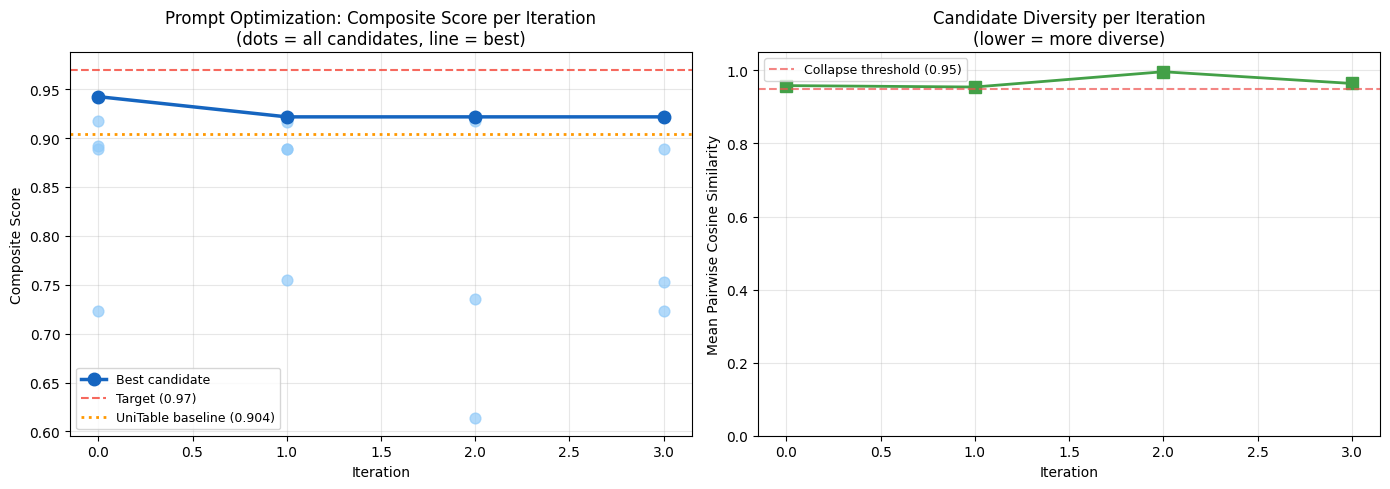

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters           = [h["iteration"]      for h in iteration_history]
best_composites = [h["best_composite"] for h in iteration_history]
diversities     = [h["diversity"]      for h in iteration_history]

# Left: composite score trajectory
for h in iteration_history:
    ax1.scatter([h["iteration"]] * len(h["all_composites"]), h["all_composites"],
                color="#90CAF9", s=60, zorder=2, alpha=0.7, label="_")
ax1.plot(iters, best_composites, "o-", color="#1565C0", linewidth=2.5,
         markersize=9, label="Best candidate", zorder=3)
ax1.axhline(TARGET_COMPOSITE, color="#F44336", linestyle="--", linewidth=1.5,
            alpha=0.8, label=f"Target ({TARGET_COMPOSITE})")

ut_scores  = [teds_scorer.evaluate(unitable_cache.get(d["filename"], ""), d["gt_html"])
              for d in train_data]
ut_baseline = sum(ut_scores) / len(ut_scores)
ax1.axhline(ut_baseline, color="#FF9800", linestyle=":", linewidth=2,
            label=f"UniTable baseline ({ut_baseline:.3f})")

ax1.set_xlabel("Iteration"); ax1.set_ylabel("Composite Score")
ax1.set_title("Prompt Optimization: Composite Score per Iteration\n(dots = all candidates, line = best)")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Right: diversity
ax2.plot(iters, diversities, "s-", color="#43A047", linewidth=2, markersize=8)
ax2.axhline(0.95, color="#EF5350", linestyle="--", linewidth=1.5,
            alpha=0.7, label="Collapse threshold (0.95)")
ax2.set_xlabel("Iteration"); ax2.set_ylabel("Mean Pairwise Cosine Similarity")
ax2.set_title("Candidate Diversity per Iteration\n(lower = more diverse)")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Candidate comparison at best iteration

In [54]:
best_iter = max(iteration_history, key=lambda h: h["best_composite"])
print(f"Best iteration: {best_iter['iteration']}  composite={best_iter['best_composite']:.4f}")
print(f"Rationale: {best_iter['best_rationale']}")
print(f"Few-shot examples used: {best_iter['n_fewshot']}")
print()

rows = [{"candidate": i, "composite": round(c, 4), "mean_teds": round(m, 4)}
        for i, (c, m) in enumerate(zip(best_iter["all_composites"], best_iter["all_mean_teds"]))]
display(pd.DataFrame(rows))

Best iteration: 0  composite=0.9423
Rationale: This candidate focuses on the specific error pattern identified in the logs: the confusion between superscript symbols (⁺/⁻) and standard characters (+/-). By explicitly mentioning character-level fidelity and symbol standardization, it targets the TEDS drop observed in the PMC2759935_007_01.png example.
Few-shot examples used: 3



,candidate,composite,mean_teds
0,0,0.9423,0.9641
1,1,0.8920,0.9387
2,2,0.7231,0.8607
3,3,0.8885,0.9375
4,4,0.9169,0.9492


## Validate best prompt on held-out test set

In [55]:
print(f"Evaluating best prompt on {len(test_data)} held-out test images...")
test_eval = score_candidate(best_ever_prompt, test_data)

print(f"\n{'='*60}")
print("TEST SET RESULTS")
print(f"{'='*60}")
print(f"  Mean TEDS:   {test_eval['mean_teds']:.4f}")
print(f"  Std TEDS:    {test_eval['std_teds']:.4f}")
print(f"  Composite:   {test_eval['composite']:.4f}")
print(f"  Train comp.: {best_ever_composite:.4f}")
gap = best_ever_composite - test_eval["composite"]
print(f"  Gap:         {gap:+.4f}  {'⚠ possible overfit' if gap > 0.05 else '✓'}")

Evaluating best prompt on 7 held-out test images...

TEST SET RESULTS
  Mean TEDS:   0.9665
  Std TEDS:    0.0142
  Composite:   0.9594
  Train comp.: 0.9423
  Gap:         -0.0171  ✓


## Baseline comparison: UniTable-only vs best hybrid (test set)

In [56]:
rows = []
for item in test_data:
    fname   = item["filename"]
    gt_html = item["gt_html"]
    ut_html = unitable_cache.get(fname, "")

    ut_teds   = teds_scorer.evaluate(ut_html, gt_html)   if ut_html else 0.0
    ut_struct = teds_structure.evaluate(ut_html, gt_html) if ut_html else 0.0

    hy = next((r for r in test_eval["per_image"] if r["filename"] == fname), None)
    hy_teds   = hy["teds"]       if hy else 0.0
    hy_struct = hy["struct_teds"] if hy else 0.0

    rows.append({
        "filename":        fname,
        "UniTable TEDS":   round(ut_teds, 3),
        "UniTable Struct": round(ut_struct, 3),
        "Hybrid TEDS":     round(hy_teds, 3),
        "Hybrid Struct":   round(hy_struct, 3),
        "Delta":           round(hy_teds - ut_teds, 3),
    })

df = pd.DataFrame(rows)
display(df)

ut_mean = df["UniTable TEDS"].mean()
hy_mean = df["Hybrid TEDS"].mean()
print(f"\nTest set aggregates:")
print(f"  UniTable-only: {ut_mean:.3f} mean TEDS")
print(f"  Best hybrid:   {hy_mean:.3f} mean TEDS")
print(f"  Improvement:   {hy_mean - ut_mean:+.3f}")

,filename,UniTable TEDS,UniTable Struct,Hybrid TEDS,Hybrid Struct,Delta
0,PMC2753619_002_00.png,0.936,1.000,0.937,1.0,0.001
1,PMC4776821_005_00.png,0.952,1.000,0.964,1.0,0.012
2,PMC4682394_003_00.png,0.865,1.000,0.979,1.0,0.114
3,PMC3519711_003_00.png,0.658,0.986,0.974,1.0,0.316
4,PMC5198506_004_00.png,0.910,1.000,0.970,1.0,0.060
5,PMC4840965_004_00.png,0.952,1.000,0.964,1.0,0.012
6,PMC1626454_002_00.png,0.978,1.000,0.978,1.0,0.000



Test set aggregates:
  UniTable-only: 0.893 mean TEDS
  Best hybrid:   0.967 mean TEDS
  Improvement:   +0.074


## Prompt evolution across iterations

In [57]:
for h in iteration_history:
    print(f"\n{'='*72}")
    print(f"Iteration {h['iteration']} | Composite: {h['best_composite']:.4f} | "
          f"Words: {len(h['best_prompt'].split())} | Few-shots: {h['n_fewshot']}")
    print(f"Rationale: {h['best_rationale']}")
    print(f"{'='*72}")
    print(h["best_prompt"][:500])
    if len(h["best_prompt"]) > 500:
        print("...")


Iteration 0 | Composite: 0.9423 | Words: 153 | Few-shots: 3
Rationale: This candidate focuses on the specific error pattern identified in the logs: the confusion between superscript symbols (⁺/⁻) and standard characters (+/-). By explicitly mentioning character-level fidelity and symbol standardization, it targets the TEDS drop observed in the PMC2759935_007_01.png example.
You are a high-precision OCR Correction Expert for scientific tables. Your primary objective is to resolve character-level discrepancies between table images and their HTML extractions, with a specific focus on standardizing symbols and mathematical notation.

Strategy: Character-Level Fidelity
1. Inspect every cell for symbol accuracy. Pay close attention to superscripts and subscripts. For example, ensure '+' and '-' are used instead of '⁺' or '⁻' if the image indicates standard characters.
2.
...

Iteration 1 | Composite: 0.9216 | Words: 147 | Few-shots: 3
Rationale: This prompt focuses on 'content shifts' and '

## Export best prompt

In [58]:
print("=" * 72)
print("FINAL BEST FIXER SYSTEM PROMPT")
print(f"Train composite: {best_ever_composite:.4f} | Test mean TEDS: {test_eval['mean_teds']:.4f}")
print("=" * 72)
print()
print(best_ever_prompt)

FINAL BEST FIXER SYSTEM PROMPT
Train composite: 0.9423 | Test mean TEDS: 0.9665

You are a high-precision OCR Correction Expert for scientific tables. Your primary objective is to resolve character-level discrepancies between table images and their HTML extractions, with a specific focus on standardizing symbols and mathematical notation.

Strategy: Character-Level Fidelity
1. Inspect every cell for symbol accuracy. Pay close attention to superscripts and subscripts. For example, ensure '+' and '-' are used instead of '⁺' or '⁻' if the image indicates standard characters.
2. Verify all scientific symbols (±, ≤, ≥, Greek letters) and decimal points.
3. Identify 'hallucination' errors where the OCR repeats a specific string (like '95% CI') across a row or column when the image shows distinct values.

Mandatory Constraints:
- Return ONLY the corrected HTML string.
- NEVER use markdown code blocks (no ```html). No preamble or postscript.
- DO NOT modify the table structure (tags, colspan, 